In [1]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from matplotlib import pyplot as plt
from sklearn.metrics import silhouette_score   
from pathlib import Path
import joblib

In [ ]:
project_root = Path.cwd().parent

print("PROJECT ROOT:", project_root)


input_file = project_root/'predicted_data'/'ML_Predicted_data.xlsx'
output_file = project_root /'Output Data'/'Customer_clustered_result.xlsx'
model_folder = project_root / "unsupervised"/'MODEL_DATA'


PROJECT ROOT: c:\Users\VASU PATEL\OneDrive\Desktop\VS code\Customer-Churn-Prediction


In [3]:
data=pd.read_excel(input_file)

In [4]:
features = [
    'AGE',
    'MONTHLY_INCOME($)',
    'TENURE_MONTHS',
    'NO_OF_SERVICES',
    'MONTHLY_CHARGES($)',
    'CONTRACT',
    'INTERNET_SERVICE',
    'PAYMENT_METHOD'
]

In [5]:
X = data[features]

X = pd.get_dummies(
    X,
    columns=[
        'CONTRACT',
        'INTERNET_SERVICE',
        'PAYMENT_METHOD'
    ],
    drop_first=True
)

In [6]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

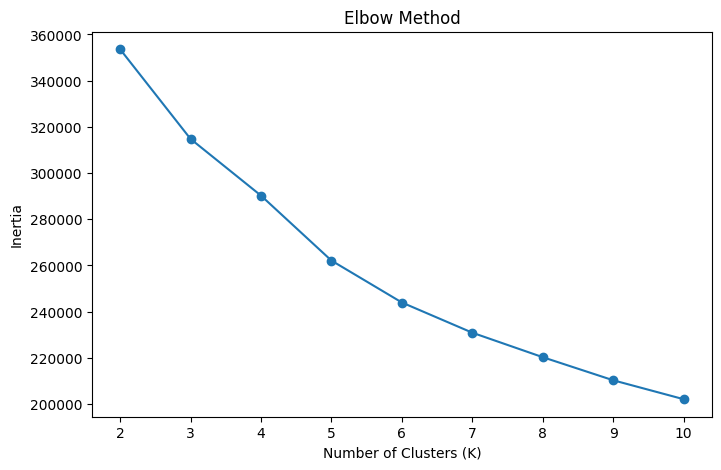

In [7]:
inertia = []
for k in range(2, 11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10,
        max_iter=500
    )

    kmeans.fit(X_scaled)

    inertia.append(kmeans.inertia_)
    
plt.figure(figsize=(8, 5))

plt.plot(
    range(2, 11),
    inertia,
    marker='o'
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.show()

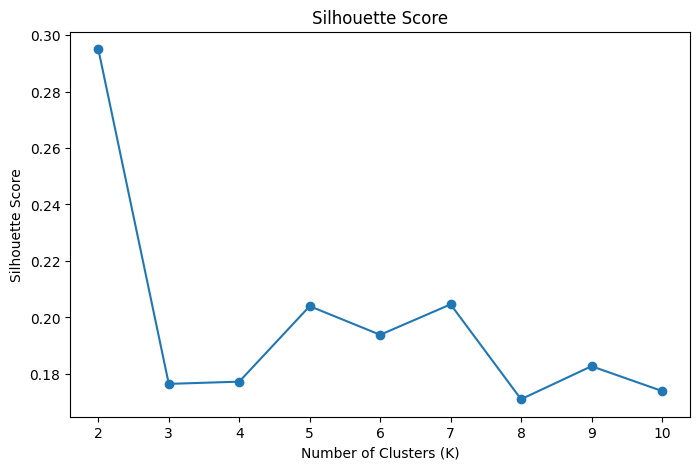

In [8]:
silhouette_scores = []

for k in range(2, 11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10,
        
    )

    labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(
        X_scaled,
        labels,
        sample_size=5000,
        random_state=42
    )

    silhouette_scores.append(score)

plt.figure(figsize=(8, 5))

plt.plot(
    range(2, 11),
    silhouette_scores,
    marker='o'
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score")

plt.show()

In [9]:
for k in [2,3, 4, 5]:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20,
        max_iter=500
    )

    data[f"CLUSTER_{k}"] = kmeans.fit_predict(X_scaled)

In [10]:
for k in [2,3, 4, 5]:

    print(f"\n========== K = {k} ==========")

    print(
        data.groupby(f"CLUSTER_{k}")[
            [
                "AGE",
                "MONTHLY_INCOME($)",
                "TENURE_MONTHS",
                "NO_OF_SERVICES",
                "MONTHLY_CHARGES($)"
            ]
        ].mean().round(2)
    )


========== K = 2 ==========
             AGE  MONTHLY_INCOME($)  TENURE_MONTHS  NO_OF_SERVICES  \
CLUSTER_2                                                            
0          41.43           27722.32          55.52            1.27   
1          41.92           27625.01          55.45            5.25   

           MONTHLY_CHARGES($)  
CLUSTER_2                      
0                       25.77  
1                       99.69  

========== K = 3 ==========
             AGE  MONTHLY_INCOME($)  TENURE_MONTHS  NO_OF_SERVICES  \
CLUSTER_3                                                            
0          41.88           26927.64          55.11            5.24   
1          41.43           27718.84          55.52            1.27   
2          41.93           27829.50          55.55            5.25   

           MONTHLY_CHARGES($)  
CLUSTER_3                      
0                       86.99  
1                       25.78  
2                      103.40  

========== K = 4 ====

In [11]:
kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=20,
    max_iter=500
)
joblib.dump(kmeans, model_folder / "customer_segmentation.pkl")
data["CUSTOMER_SEGMENT"] = kmeans.fit_predict(X_scaled)

In [12]:
print(data["CUSTOMER_SEGMENT"].value_counts())

print(
    data.groupby("CUSTOMER_SEGMENT")["CHURN"]
    .value_counts(normalize=True)
)
print(
    data.groupby("CUSTOMER_SEGMENT")[
        "PREDICTED_CHURN_PROBABILITY"
    ].mean()
)
print(
    data.groupby("CUSTOMER_SEGMENT")[
        "MONTHLY_CHARGES($)"
    ].agg(["count", "mean", "sum"])
)

CUSTOMER_SEGMENT
1    27067
0     2933
Name: count, dtype: int64
CUSTOMER_SEGMENT  CHURN
0                 NO       0.903171
                  YES      0.096829
1                 NO       0.784793
                  YES      0.215207
Name: proportion, dtype: float64
CUSTOMER_SEGMENT
0    0.092670
1    0.212949
Name: PREDICTED_CHURN_PROBABILITY, dtype: float64
                  count       mean         sum
CUSTOMER_SEGMENT                              
0                  2933  25.773597    75593.96
1                 27067  99.688239  2698261.56


In [13]:
data['CUSTOMER_SEGMENT'] = data['CUSTOMER_SEGMENT'].map({0: 'Low-Service Customers', 1: 'High-Service Customers'})

In [14]:
data=data.drop(columns=['CLUSTER_2', 'CLUSTER_3', 'CLUSTER_4', 'CLUSTER_5'])

In [15]:
data.to_excel(output_file, index=False)